# E-Commerce Customer Analytics
## Phase 4 — K-Means Clustering
**Dataset:** Olist Brazilian E-Commerce (RFM Scores from Phase 3)  
**Goal:** Use machine learning to discover natural customer groupings in the data,
complementing and validating the rule-based RFM segments from Phase 3.

### Why Clustering After RFM?
RFM segmentation is rule-based — we manually define which score combinations
map to which segment. K-Means Clustering is data-driven — the algorithm finds
natural groupings on its own, without us telling it where the boundaries are.

Using both approaches together gives us stronger, more defensible segments:
- RFM tells us **what** each segment means in business terms
- K-Means tells us whether the data itself **agrees** with those groupings

### What is K-Means?
K-Means is one of the most widely used clustering algorithms. It works by:
1. Placing K random centre points in the data
2. Assigning every customer to their nearest centre
3. Moving each centre to the average position of its assigned customers
4. Repeating steps 2-3 until the centres stop moving

The result is K groups of customers who are similar to each other and
different from customers in other groups.

---
## 1. Import Libraries & Configure Paths

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os
import warnings

# scikit-learn: the standard Python machine learning library
from sklearn.preprocessing import StandardScaler      # normalises features to same scale
from sklearn.cluster import KMeans                    # the K-Means algorithm
from sklearn.metrics import silhouette_score          # measures cluster quality
from sklearn.decomposition import PCA                 # reduces dimensions for visualisation

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

PROJECT_ROOT   = os.path.expanduser('~/Desktop/ecommerce-customer-analytics')
PROCESSED_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed') + '/'
DOCS_PATH      = os.path.join(PROJECT_ROOT, 'docs')
os.makedirs(DOCS_PATH, exist_ok=True)

print('Libraries loaded ✅')

Libraries loaded ✅


---
## 2. Load the RFM Data
We load the RFM scores produced in Phase 3. Each row is a unique customer
with their Recency, Frequency, Monetary values and RFM segment already assigned.

In [46]:
# Load the RFM table from Phase 3
rfm = pd.read_csv(PROCESSED_PATH + 'rfm_scores.csv')

print(f'RFM table loaded: {rfm.shape[0]:,} customers, {rfm.shape[1]} columns')
print(f'\nColumns: {list(rfm.columns)}')
print(f'\nSample rows:')
print(rfm[['customer_unique_id', 'recency', 'frequency', 'monetary', 'segment']].head())

RFM table loaded: 93,323 customers, 10 columns

Columns: ['customer_unique_id', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_total', 'segment']

Sample rows:
                 customer_unique_id  recency  frequency  monetary  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19   
2  0000f46a3911fa3c0805444483337064      537          1     86.22   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89   

               segment  
0  Potential Loyalists  
1  Potential Loyalists  
2          Hibernating  
3       About to Sleep  
4       About to Sleep  


---
## 3. Prepare Features for Clustering
K-Means works on raw numeric values, not on the 1-5 scores we created in Phase 3.
We use the original Recency, Frequency, and Monetary values directly.

We also remove revenue outliers before clustering — extreme values would pull
cluster centres toward them and create unbalanced groups.

In [47]:
# Load master table to access the outlier flag from Phase 2
master = pd.read_csv(PROCESSED_PATH + 'master_orders_clean.csv')

# Get the set of customers flagged as revenue outliers
# We identify them via orders with the outlier flag, then find their unique IDs
outlier_customers = master[master['is_revenue_outlier'] == True]['customer_unique_id'].unique()

# Filter out outlier customers from the RFM table
rfm_clean = rfm[~rfm['customer_unique_id'].isin(outlier_customers)].copy()

print(f'Customers before outlier removal: {len(rfm):,}')
print(f'Customers after outlier removal:  {len(rfm_clean):,}')
print(f'Outlier customers removed:        {len(rfm) - len(rfm_clean):,}')

# Select the three raw RFM dimensions as clustering features
# We use raw values (not 1-5 scores) so K-Means can find its own natural boundaries
features = rfm_clean[['recency', 'frequency', 'monetary']].copy()

print(f'\nFeature summary:')
print(features.describe().round(2))

Customers before outlier removal: 93,323
Customers after outlier removal:  85,827
Outlier customers removed:        7,496

Feature summary:
        recency  frequency  monetary
count  85827.00   85827.00  85827.00
mean     237.73       1.03    118.64
std      152.24       0.20     77.14
min        1.00       1.00      9.59
25%      115.00       1.00     59.98
50%      219.00       1.00     99.43
75%      346.00       1.00    159.40
max      695.00      15.00   1122.72


---
## 4. Scale the Features
K-Means calculates distances between points. If one feature has a much larger
range than another (e.g. monetary values in hundreds vs frequency of 1-5),
it will dominate the distance calculation and distort the clusters.

StandardScaler transforms each feature to have a mean of 0 and a standard
deviation of 1 — putting all three features on equal footing.

In [48]:
# Initialise the scaler
scaler = StandardScaler()

# fit_transform() learns the mean and std of each column, then scales the data
# The result is a numpy array — we convert it back to a DataFrame for readability
features_scaled = scaler.fit_transform(features)
features_scaled_df = pd.DataFrame(
    features_scaled,
    columns=['recency_scaled', 'frequency_scaled', 'monetary_scaled']
)

print('Features before scaling (first 3 rows):')
print(features.head(3).to_string())
print('\nFeatures after scaling (first 3 rows):')
print(features_scaled_df.head(3).round(4).to_string())
print('\nScaled feature means (should all be ~0):')
print(features_scaled_df.mean().round(4).to_string())
print('\nScaled feature std devs (should all be ~1):')
print(features_scaled_df.std().round(4).to_string())

Features before scaling (first 3 rows):
   recency  frequency  monetary
0      112          1    141.90
1      115          1     27.19
2      537          1     86.22

Features after scaling (first 3 rows):
   recency_scaled  frequency_scaled  monetary_scaled
0         -0.8259           -0.1581           0.3016
1         -0.8062           -0.1581          -1.1855
2          1.9659           -0.1581          -0.4203

Scaled feature means (should all be ~0):
recency_scaled     -0.0
frequency_scaled   -0.0
monetary_scaled    -0.0

Scaled feature std devs (should all be ~1):
recency_scaled      1.0
frequency_scaled    1.0
monetary_scaled     1.0


---
## 5. Find the Optimal Number of Clusters (K)
K-Means requires us to specify K (the number of clusters) upfront.
We use two complementary methods to find the best value:

- **Elbow Method**: plots inertia (total within-cluster distance) vs K.
  The 'elbow' — where the curve bends — is where adding more clusters
  stops meaningfully improving the fit.

- **Silhouette Score**: measures how similar each customer is to their own
  cluster vs neighbouring clusters. Ranges from -1 to 1 — higher is better.
  The K with the highest score is the most well-separated.

In [49]:
# Test K values from 2 to 10
k_range = range(2, 11)
inertias = []       # stores within-cluster sum of squares for each K
silhouettes = []    # stores silhouette score for each K

print('Testing K values...')
for k in k_range:
    # n_init=10: run K-Means 10 times with different random starts, keep the best
    # random_state=42: ensures reproducibility — same results every run
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(features_scaled)

    inertias.append(km.inertia_)

    # Silhouette score requires at least 2 clusters and is computationally heavier
    # sample_size=5000 speeds it up without meaningfully affecting accuracy
    sil = silhouette_score(features_scaled, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f'  K={k}: Inertia={km.inertia_:,.0f} | Silhouette={sil:.4f}')

print('\nDone ✅')

Testing K values...
  K=2: Inertia=179,810 | Silhouette=0.7104
  K=3: Inertia=121,013 | Silhouette=0.3674
  K=4: Inertia=81,888 | Silhouette=0.4111
  K=5: Inertia=70,186 | Silhouette=0.3549
  K=6: Inertia=60,059 | Silhouette=0.3669
  K=7: Inertia=51,535 | Silhouette=0.3683
  K=8: Inertia=44,945 | Silhouette=0.3726
  K=9: Inertia=40,581 | Silhouette=0.3735
  K=10: Inertia=36,878 | Silhouette=0.3733

Done ✅


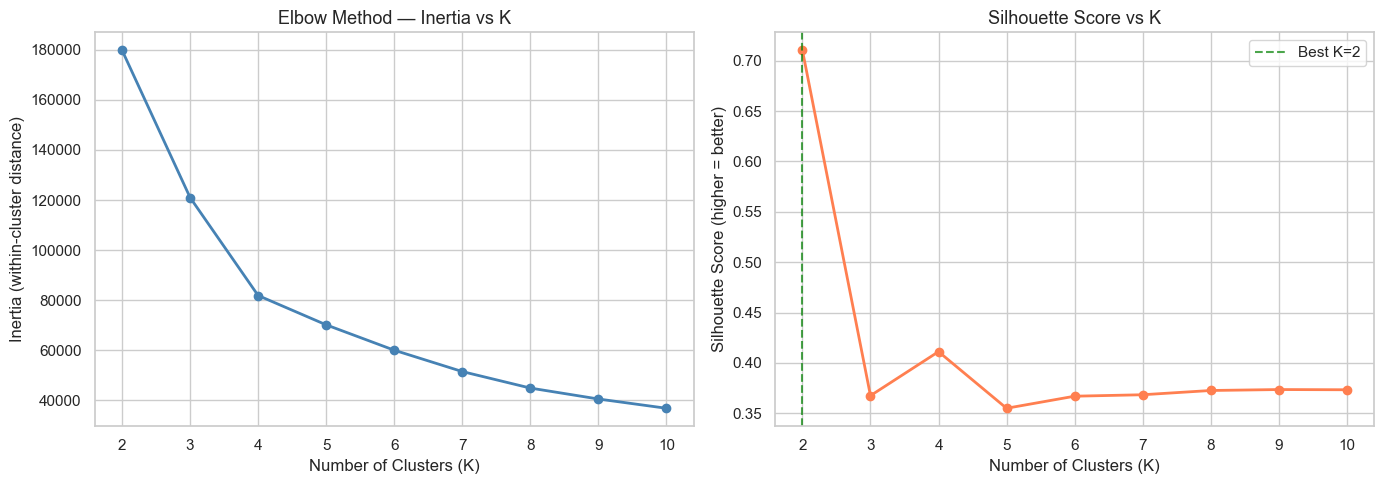

Best K by Silhouette Score: 2

Review the elbow curve above and choose K where the bend is sharpest.
If elbow and silhouette agree, that K is a strong choice.


In [50]:
# Plot both metrics side by side to help choose the best K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Elbow curve ---
# Look for the 'elbow' — the point where inertia stops dropping sharply
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster distance)')
axes[0].set_xticks(list(k_range))

# --- Right: Silhouette scores ---
# Higher = better separated clusters. Look for the peak.
axes[1].plot(list(k_range), silhouettes, marker='o', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_xticks(list(k_range))

# Mark the best silhouette score
best_k_sil = list(k_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=best_k_sil, color='green', linestyle='--', alpha=0.7,
                label=f'Best K={best_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'clustering_optimal_k.png'), dpi=150)
plt.show()

print(f'Best K by Silhouette Score: {best_k_sil}')
print('\nReview the elbow curve above and choose K where the bend is sharpest.')
print('If elbow and silhouette agree, that K is a strong choice.')

---
## 6. Fit the Final K-Means Model
Based on the elbow and silhouette analysis above, we select the optimal K
and fit the final model.

In [51]:
# Set the optimal K based on the elbow and silhouette analysis
# The silhouette score picks this automatically — review the charts above
# and override if you see a clearer elbow at a different value
OPTIMAL_K = 3
print(f'Using K = {OPTIMAL_K}')

# Fit the final K-Means model with the chosen K
# n_init=20: more restarts than during evaluation for a more stable final model
kmeans = KMeans(n_clusters=OPTIMAL_K, n_init=20, random_state=42)
rfm_clean['cluster'] = kmeans.fit_predict(features_scaled)

# Cluster labels from K-Means are arbitrary integers (0, 1, 2...)
# We will rename them to meaningful labels after analysing the profiles
print(f'\nCluster assignment counts:')
print(rfm_clean['cluster'].value_counts().sort_index())

Using K = 3

Cluster assignment counts:
cluster
0    34062
1    49277
2     2488
Name: count, dtype: int64


---
## 7. Profile Each Cluster
K-Means gives us numbered clusters, but numbers mean nothing on their own.
We need to understand what kind of customer each cluster represents by
looking at the average RFM values for each group.

In [52]:
# Calculate mean RFM values per cluster
# This tells us the 'personality' of each cluster
cluster_profiles = rfm_clean.groupby('cluster').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_rfm_total=('RFM_total', 'mean')
).round(1).reset_index()

# Add revenue share
cluster_profiles['revenue_share_%'] = (
    rfm_clean.groupby('cluster')['monetary'].sum() /
    rfm_clean['monetary'].sum() * 100
).round(1).values

print('Cluster Profiles:')
print(cluster_profiles.to_string(index=False))
print()
print('Interpretation guide:')
print('  Low recency + High frequency + High monetary = Best customers')
print('  High recency + Low frequency + Low monetary  = Least active customers')

Cluster Profiles:
 cluster  customer_count  avg_recency  avg_frequency  avg_monetary  avg_rfm_total  revenue_share_%
       0           34062        391.6            1.0         109.1            7.2             36.5
       1           49277        132.2            1.0         119.4            9.8             57.8
       2            2488        221.0            2.1         234.7           12.3              5.7

Interpretation guide:
  Low recency + High frequency + High monetary = Best customers
  High recency + Low frequency + Low monetary  = Least active customers


### 7b. Assign Meaningful Cluster Labels
Based on the profiles above, we assign a descriptive name to each cluster.
Review the cluster profiles printout and update the mapping below to match
what you observe in your data.

In [53]:
# Automatically rank clusters by RFM total score to assign tier labels
# Sort clusters by avg_rfm_total descending (highest = best customers)
ranked = cluster_profiles.sort_values('avg_rfm_total', ascending=False).reset_index(drop=True)

# Define tier labels from best to least engaged
# These will be adjusted based on how many clusters K-Means found
tier_labels = [
    'High Value',
    'Loyal',
    'Promising',
    'At Risk',
    'Inactive',
    'Lost',
    'Uncertain',
    'Emerging',
    'Dormant',
    'Minimal'
]

# Build a mapping from cluster number to label
cluster_label_map = {
    row['cluster']: tier_labels[i]
    for i, row in ranked.iterrows()
}

# Apply labels to the RFM dataframe
rfm_clean['cluster_label'] = rfm_clean['cluster'].map(cluster_label_map)

print('Cluster label mapping:')
for k, v in sorted(cluster_label_map.items()):
    print(f'  Cluster {k} → {v}')

print('\nFinal cluster distribution:')
print(rfm_clean['cluster_label'].value_counts())

Cluster label mapping:
  Cluster 0.0 → Promising
  Cluster 1.0 → Loyal
  Cluster 2.0 → High Value

Final cluster distribution:
cluster_label
Loyal         49277
Promising     34062
High Value     2488
Name: count, dtype: int64


---
## 8. Visualise the Clusters
### 8a. Cluster Profiles — Radar / Bar Comparison

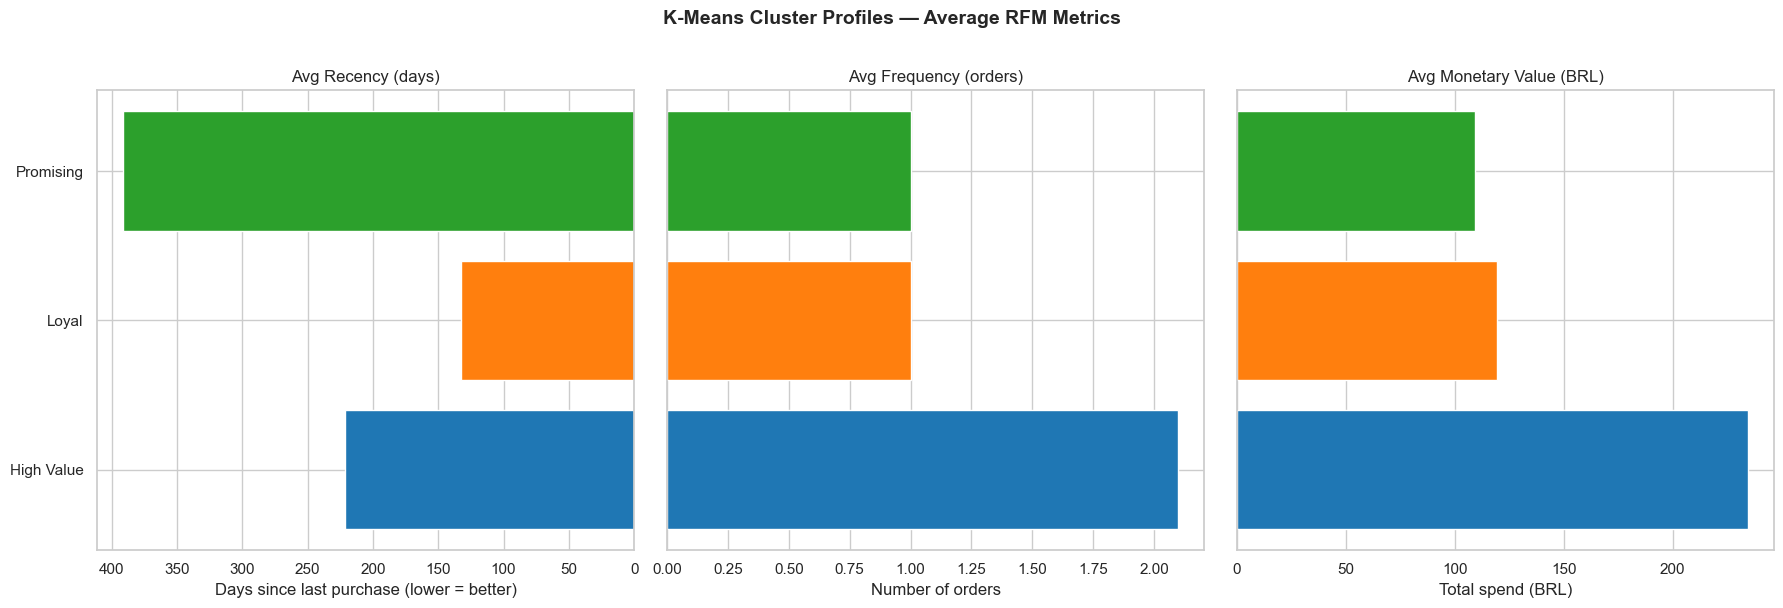

In [54]:
# Add labels to profile table for plotting
cluster_profiles['label'] = cluster_profiles['cluster'].map(cluster_label_map)
cluster_profiles = cluster_profiles.sort_values('avg_rfm_total', ascending=False)

# Define consistent colors per cluster
palette = sns.color_palette('tab10', n_colors=OPTIMAL_K)
color_map = dict(zip(cluster_profiles['label'], palette))
bar_colors = [color_map[l] for l in cluster_profiles['label']]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Recency (inverted axis — lower days = more recent = better)
axes[0].barh(cluster_profiles['label'], cluster_profiles['avg_recency'], color=bar_colors)
axes[0].set_title('Avg Recency (days)', fontsize=12)
axes[0].set_xlabel('Days since last purchase (lower = better)')
axes[0].invert_xaxis()

# Frequency
axes[1].barh(cluster_profiles['label'], cluster_profiles['avg_frequency'], color=bar_colors)
axes[1].set_title('Avg Frequency (orders)', fontsize=12)
axes[1].set_xlabel('Number of orders')
axes[1].set_yticklabels([])

# Monetary
axes[2].barh(cluster_profiles['label'], cluster_profiles['avg_monetary'], color=bar_colors)
axes[2].set_title('Avg Monetary Value (BRL)', fontsize=12)
axes[2].set_xlabel('Total spend (BRL)')
axes[2].set_yticklabels([])

plt.suptitle('K-Means Cluster Profiles — Average RFM Metrics', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'clustering_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()

### 8b. Cluster Size & Revenue Contribution

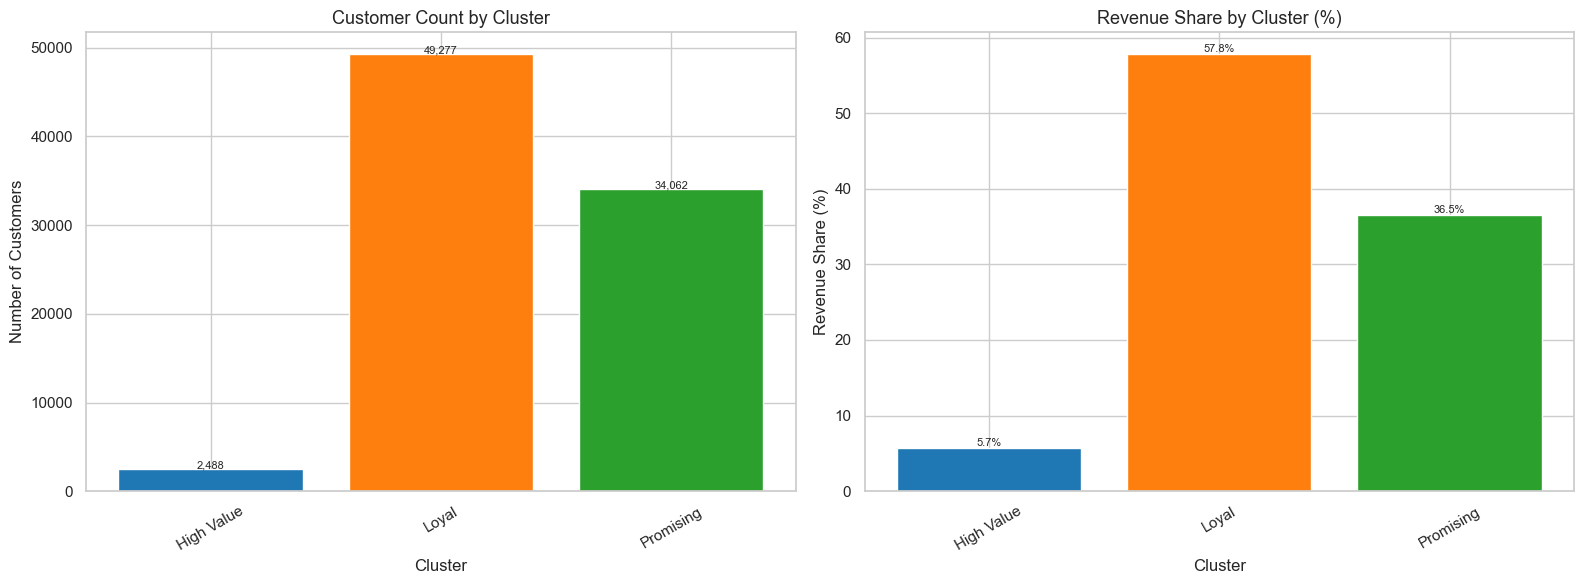

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Customer count per cluster
sizes = cluster_profiles.set_index('label')['customer_count']
c = [color_map[l] for l in sizes.index]
axes[0].bar(sizes.index, sizes.values, color=c)
axes[0].set_title('Customer Count by Cluster', fontsize=13)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(sizes.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=8)

# Revenue share per cluster
rev_share = cluster_profiles.set_index('label')['revenue_share_%']
axes[1].bar(rev_share.index, rev_share.values, color=c)
axes[1].set_title('Revenue Share by Cluster (%)', fontsize=13)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Revenue Share (%)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(rev_share.values):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'clustering_size_revenue.png'), dpi=150)
plt.show()

### 8c. 2D Cluster Visualisation Using PCA
K-Means operates in 3D (R, F, M). We use PCA (Principal Component Analysis)
to compress these three dimensions into two so we can plot the clusters.
This is for visualisation only — the actual clustering used all three dimensions.

Variance explained by 2 PCA components: 75.9%


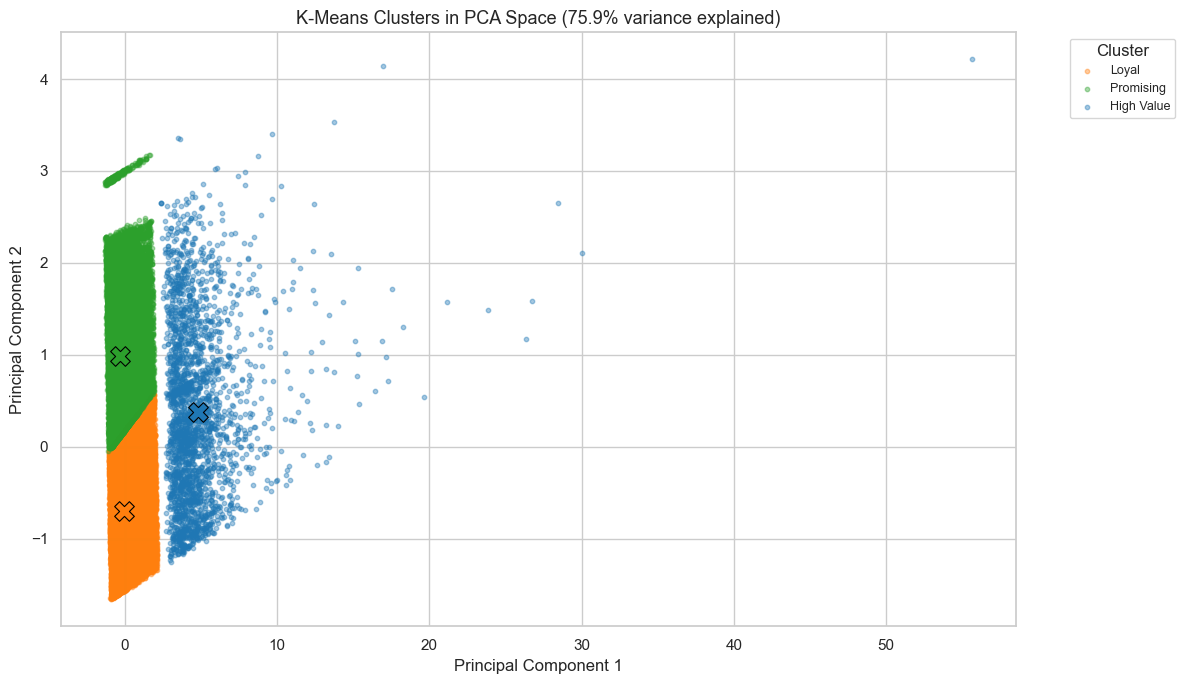

In [56]:
# PCA reduces our 3 scaled features to 2 components for 2D plotting
# n_components=2 means we want 2 output dimensions
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(features_scaled)

# How much of the original variance is captured by the 2 components?
# Higher = more faithful representation of the original 3D data
variance_explained = pca.explained_variance_ratio_.sum() * 100
print(f'Variance explained by 2 PCA components: {variance_explained:.1f}%')

# Build a DataFrame with PCA coordinates and cluster labels for plotting
pca_df = pd.DataFrame(pca_coords, columns=['PC1', 'PC2'])
pca_df['cluster_label'] = rfm_clean['cluster_label'].values

plt.figure(figsize=(12, 7))
for label in pca_df['cluster_label'].unique():
    subset = pca_df[pca_df['cluster_label'] == label]
    # alpha=0.4 makes overlapping points visible
    plt.scatter(subset['PC1'], subset['PC2'],
                label=label, alpha=0.4, s=10,
                color=color_map.get(label, 'grey'))

# Plot cluster centres projected onto the PCA space
centres_pca = pca.transform(kmeans.cluster_centers_)
for i, centre in enumerate(centres_pca):
    label = cluster_label_map[i]
    plt.scatter(centre[0], centre[1], s=200, marker='X',
                color=color_map.get(label, 'black'),
                edgecolors='black', linewidths=0.8, zorder=5)

plt.title(f'K-Means Clusters in PCA Space ({variance_explained:.1f}% variance explained)',
          fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'clustering_pca_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Compare K-Means Clusters with RFM Segments
How well do the machine learning clusters align with the rule-based RFM segments?
A heatmap showing how customers are distributed across both classification systems
tells us whether the two approaches agree.

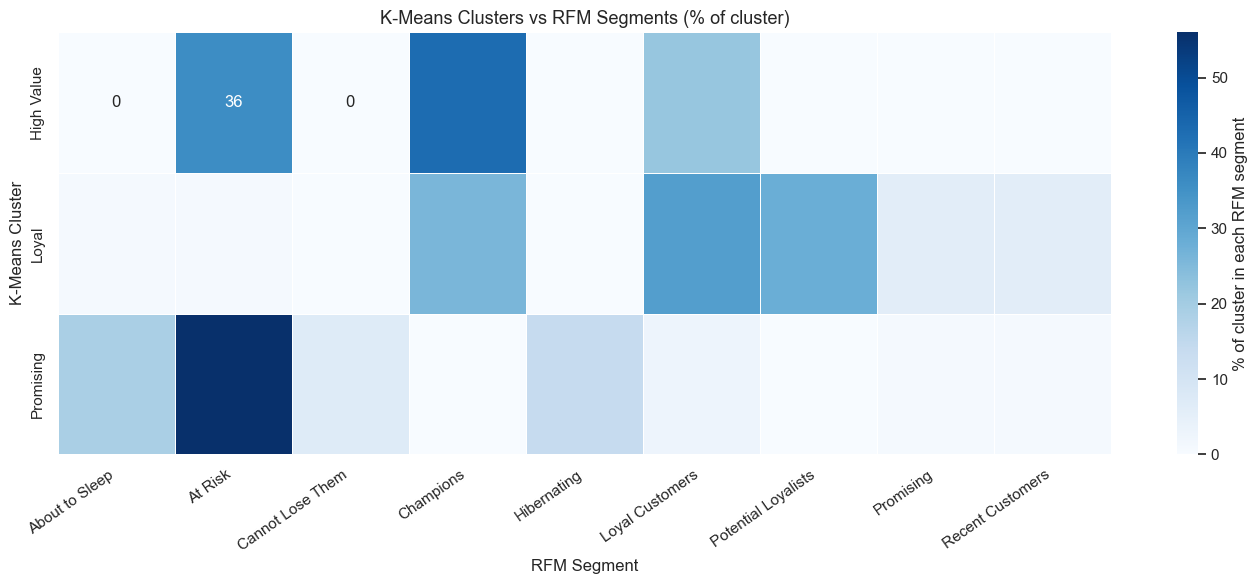

Strong diagonal concentration = K-Means and RFM agree.
Spread across many cells = the two approaches diverge.


In [57]:
# Cross-tabulate K-Means cluster labels vs RFM segment labels
# Each cell shows how many customers share both classifications
crosstab = pd.crosstab(
    rfm_clean['cluster_label'],
    rfm_clean['segment'],
    normalize='index'  # normalise by row so each cluster sums to 100%
).round(2) * 100

plt.figure(figsize=(14, 6))
sns.heatmap(
    crosstab,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': '% of cluster in each RFM segment'}
)
plt.title('K-Means Clusters vs RFM Segments (% of cluster)', fontsize=13)
plt.xlabel('RFM Segment')
plt.ylabel('K-Means Cluster')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'clustering_vs_rfm_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Strong diagonal concentration = K-Means and RFM agree.')
print('Spread across many cells = the two approaches diverge.')

---
## 10. Silhouette Plot
A silhouette plot shows how well each individual customer fits within their
assigned cluster. Wide, smooth bands indicate well-separated, cohesive clusters.
Thin bands or negative values indicate customers that would fit better elsewhere.

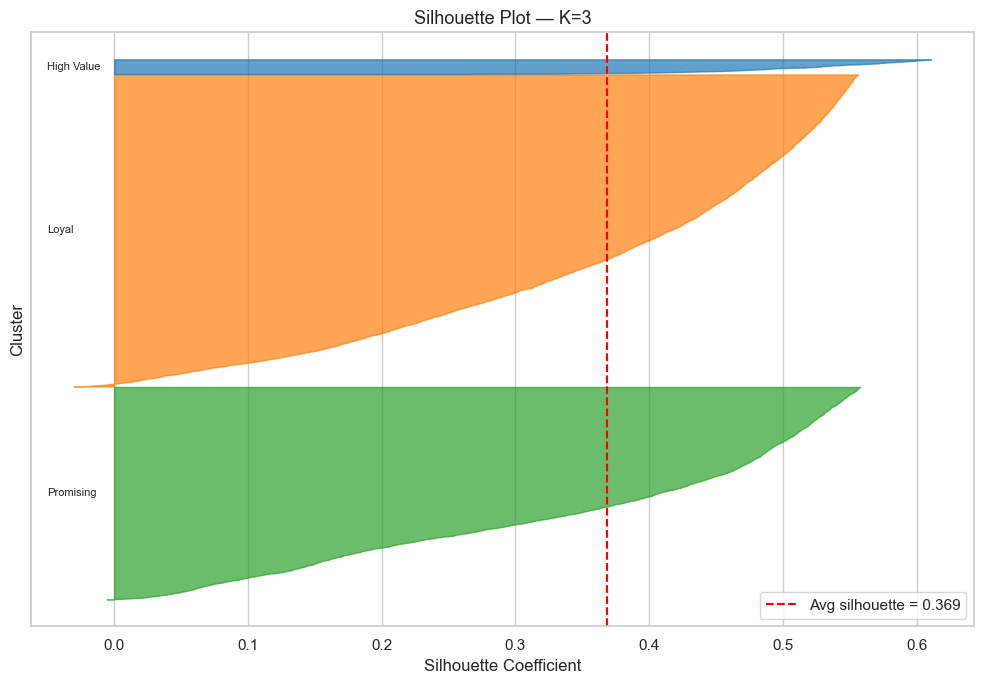

Average Silhouette Score: 0.3686
Score interpretation: >0.5 = strong | 0.25-0.5 = moderate | <0.25 = weak


In [58]:
from sklearn.metrics import silhouette_samples

# Compute silhouette score for every customer
# This is expensive on large datasets — we sample 10,000 for speed
sample_size = min(10000, len(features_scaled))
sample_idx = np.random.choice(len(features_scaled), sample_size, replace=False)
sample_features = features_scaled[sample_idx]
sample_labels   = rfm_clean['cluster'].values[sample_idx]
sample_cl_labels = rfm_clean['cluster_label'].values[sample_idx]

sil_vals = silhouette_samples(sample_features, sample_labels)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for cluster_num in sorted(rfm_clean['cluster'].unique()):
    label = cluster_label_map[cluster_num]
    # Get silhouette values for this cluster and sort them
    cluster_sil = sil_vals[sample_labels == cluster_num]
    cluster_sil.sort()

    size = len(cluster_sil)
    y_upper = y_lower + size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_sil,
        alpha=0.7,
        color=color_map.get(label, 'grey')
    )
    # Label each band at its midpoint
    ax.text(-0.05, y_lower + size / 2, label, fontsize=8, va='center')
    y_lower = y_upper + 10

# Average silhouette score as a dashed vertical line
avg_sil = sil_vals.mean()
ax.axvline(x=avg_sil, color='red', linestyle='--',
           label=f'Avg silhouette = {avg_sil:.3f}')
ax.set_title(f'Silhouette Plot — K={OPTIMAL_K}', fontsize=13)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'clustering_silhouette_plot.png'), dpi=150)
plt.show()

print(f'Average Silhouette Score: {avg_sil:.4f}')
print('Score interpretation: >0.5 = strong | 0.25-0.5 = moderate | <0.25 = weak')

---
## 11. Final Cluster Summary

In [59]:
print('=' * 65)
print('K-MEANS CLUSTERING SUMMARY')
print('=' * 65)
print(f'Optimal K selected:        {OPTIMAL_K}')
print(f'Customers clustered:       {len(rfm_clean):,}')
print(f'Average Silhouette Score:  {avg_sil:.4f}')
print(f'PCA variance explained:    {variance_explained:.1f}%')
print()

final_summary = rfm_clean.groupby('cluster_label').agg(
    customers=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_orders=('frequency', 'mean'),
    avg_spend=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(1)
final_summary['revenue_%'] = (final_summary['total_revenue'] /
                               final_summary['total_revenue'].sum() * 100).round(1)
final_summary = final_summary.sort_values('avg_spend', ascending=False)

print(final_summary.to_string())
print('=' * 65)
print('\n✅ Clustering complete. Proceed to Phase 5 — Sales Forecasting.')

K-MEANS CLUSTERING SUMMARY
Optimal K selected:        3
Customers clustered:       85,827
Average Silhouette Score:  0.3686
PCA variance explained:    75.9%

               customers  avg_recency  avg_orders  avg_spend  total_revenue  revenue_%
cluster_label                                                                         
High Value          2488        221.0         2.1      234.7       583868.1        5.7
Loyal              49277        132.2         1.0      119.4      5882024.1       57.8
Promising          34062        391.6         1.0      109.1      3716433.8       36.5

✅ Clustering complete. Proceed to Phase 5 — Sales Forecasting.


---
## 12. Save the Clustered Data

In [61]:
# Save the full RFM table with cluster assignments
# This output is used for the Tableau dashboard in Phase 6
cluster_output_path = os.path.join(PROCESSED_PATH, 'rfm_clusters.csv')
rfm_clean.to_csv(cluster_output_path, index=False)

# Save the cluster profile summary
profile_output_path = os.path.join(PROCESSED_PATH, 'cluster_profiles.csv')
cluster_profiles.to_csv(profile_output_path, index=False)

print(f'✅ Clustered RFM data saved to:  {cluster_output_path}')
print(f'✅ Cluster profiles saved to:    {profile_output_path}')
print(f'Rows: {len(rfm_clean):,} | Columns: {rfm_clean.shape[1]}')

✅ Clustered RFM data saved to:  /Users/omartouzani/Desktop/ecommerce-customer-analytics/data/processed/rfm_clusters.csv
✅ Cluster profiles saved to:    /Users/omartouzani/Desktop/ecommerce-customer-analytics/data/processed/cluster_profiles.csv
Rows: 85,827 | Columns: 12
